# Load pytorch model

In [1]:
import os
import time
import requests
from tqdm import tqdm

import diffusers
import torch

mode = 32

if mode != 16:
    # Verify checkpoints/model-16 folder exists
    if not os.path.exists("checkpoints/model-16"):
        raise ValueError("checkpoints/model-16 folder does not exist")

/root/bt-23-inferring/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def download_checkpoint(download_url, checkpoint_file):
    if os.path.exists(checkpoint_file):
        print(f"{checkpoint_file} already exists. Skipping download.")
        return

    folder, filename = os.path.split(checkpoint_file)
    os.makedirs(folder, exist_ok=True)
    with requests.get(download_url, stream=True) as response:
        total_size = int(response.headers.get("content-length", 0))
        with open(checkpoint_file, "wb") as file_stream, tqdm(
            desc=checkpoint_file,
            total=total_size,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
        ) as progress_bar:
            for data in response.iter_content(chunk_size=1024):
                file_stream.write(data)
                progress_bar.update(len(data))

    print("Download completed successfully.")
download_checkpoint("https://civitai.com/api/download/models/173961", "checkpoints/AnimeV3.safetensors")

checkpoints/AnimeV3.safetensors already exists. Skipping download.


In [3]:
from diffusers import (
    DPMSolverMultistepScheduler,
    EulerDiscreteScheduler,
    EulerAncestralDiscreteScheduler
)

def set_scheduler(scheduler_name: str, config):
    if scheduler_name == "dpm++2m_karras":
        scheduler = DPMSolverMultistepScheduler.from_config(
            config, use_karras_sigmas=True
        )
    elif scheduler_name == "euler":
        scheduler = EulerDiscreteScheduler.from_config(
            config
        )
    elif scheduler_name == "euler_ancestral":
        scheduler = EulerAncestralDiscreteScheduler.from_config(
            config
        )
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}")

    return scheduler

txt2img_pipe = diffusers.StableDiffusionXLPipeline.from_single_file(
    "checkpoints/AnimeV3.safetensors",
    use_safetensors=True,
    torch_dtype=torch.float16 if mode == 16 else torch.float32
)
scheduler_name = "dpm++2m_karras"
# scheduler_name = "euler"
# scheduler_name = "euler_ancestral"
txt2img_pipe.scheduler = set_scheduler(
    scheduler_name, txt2img_pipe.scheduler.config
)
txt2img_pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
Loading pipeline components...: 100%|██████████| 7/7 [00:02<00:00,  3.27it/s]


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.28.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DPMSolverMultistepScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [4]:
torch.manual_seed(42)
prompt = "sailing ship in storm by Leonardo da Vinci"
negative_prompt = "out of frame, nude, duplicate, watermark, signature, mutated, text, blurry, worst quality, low quality, artificial, texture artifacts, jpeg artifacts"
t1 = time.time()
image = txt2img_pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=25, 
                     guidance_scale=7, width=1024, height=1024, 
                     num_images_per_prompt = 1).images[0]
time.time() - t1

 48%|████▊     | 12/25 [00:04<00:05,  2.54it/s]

100%|██████████| 25/25 [00:09<00:00,  2.55it/s]


10.409605026245117

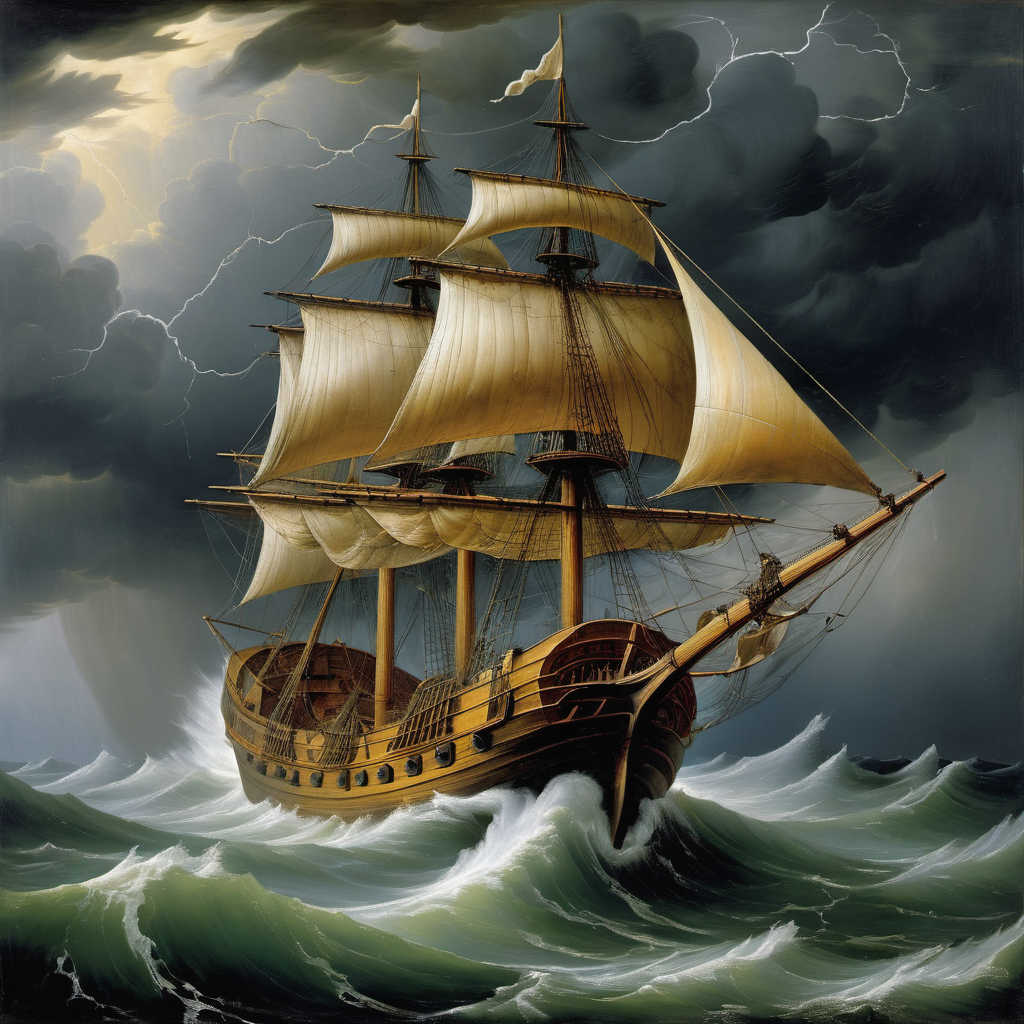

In [5]:
image

In [6]:
import shutil

path = "checkpoints/model-16" if mode == 16 else "checkpoints/model"

txt2img_pipe.save_pretrained(path, safe_serialization=True, torch_dtype=torch.float16 if mode == 16 else torch.float32)

if mode != 16:
    # Copy file checkpoints/model-16/unet/diffusion_pytorch_model.fp16.safetensors to checkpoints/model/unet/diffusion_pytorch_model.fp16.safetensors
    shutil.copy("checkpoints/model-16/unet/diffusion_pytorch_model.safetensors", "checkpoints/model/unet/diffusion_pytorch_model.fp16.safetensors")

    # Copy file checkpoints/model-16/vae/diffusion_pytorch_model.fp16.safetensors to checkpoints/model/vae/diffusion_pytorch_model.fp16.safetensors
    shutil.copy("checkpoints/model-16/vae/diffusion_pytorch_model.safetensors", "checkpoints/model/vae/diffusion_pytorch_model.fp16.safetensors")